# Лабораторная работа №6
## Необходимые и достаточные условия существования условного экстремума

**Дисциплина:** Технологии машинного обучения (модуль оптимизации)

**Цель работы:**
1. Исследование необходимых и достаточных условий существования экстремума функции с учётом ограничений (условный экстремум).
2. Вычисление экстремумов функции.

**Состав работы:**
1. Постановка задачи (вариант 1.1).
2. Аналитическое исследование через функцию Лагранжа.
3. Проверка необходимых условий первого порядка.
4. Проверка достаточных и необходимых условий второго порядка (двумя способами).
5. Численная проверка через `scipy.optimize.minimize`.
6. Визуализация задачи и найденных экстремумов.

## 1. Постановка задачи

Решается вариант **1.1** из методических указаний.

Найти условный экстремум функции

$$f(x_1, x_2) = (x_1 - 2)^2 + (x_2 - 3)^2 \;\to\; \mathrm{extr}$$

при ограничениях

$$
g_1(x) = x_1^2 + x_2^2 - 5 = 0,\qquad
g_2(x) = -x_1 \le 0,\qquad
g_3(x) = -x_2 \le 0.
$$

Геометрически: квадрат расстояния от точки $A = (2, 3)$ до точки на окружности радиуса $\sqrt{5}$ с центром в начале координат, при условии $x_1 \ge 0,\ x_2 \ge 0$ (первый квадрант). Так как $\|A\| = \sqrt{13} > \sqrt{5}$, точка $A$ лежит снаружи окружности.

**Обобщённая функция Лагранжа:**

$$L(x, \lambda_0, \lambda_1, \lambda_2, \lambda_3) = \lambda_0 \bigl[(x_1-2)^2 + (x_2-3)^2\bigr] + \lambda_1 (x_1^2 + x_2^2 - 5) + \lambda_2 (-x_1) + \lambda_3 (-x_2).$$

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.optimize import minimize, NonlinearConstraint

plt.rcParams['figure.dpi'] = 110
np.set_printoptions(precision=4, suppress=True)

## 2. Аналитическое исследование (sympy)

Запишем функцию Лагранжа и условия стационарности. Рассмотрим **регулярный случай** $\lambda_0 = 1$ (классическая функция Лагранжа); нерегулярный случай $\lambda_0 = 0$ для данной задачи противоречив, поскольку градиент $g_1$ не равен нулю на окружности.

In [2]:
x1, x2 = sp.symbols('x1 x2', real=True)
l1, l2, l3 = sp.symbols('lambda1 lambda2 lambda3', real=True)

f = (x1 - 2)**2 + (x2 - 3)**2
g1 = x1**2 + x2**2 - 5
g2 = -x1
g3 = -x2

L = f + l1 * g1 + l2 * g2 + l3 * g3
sp.simplify(L)

lambda1*(x1**2 + x2**2 - 5) - lambda2*x1 - lambda3*x2 + (x1 - 2)**2 + (x2 - 3)**2

### 2.1. Необходимые условия первого порядка (КKТ)

$$\frac{\partial L}{\partial x_1} = 0,\quad \frac{\partial L}{\partial x_2} = 0,\quad g_1 = 0,\quad \lambda_2 g_2 = 0,\ \lambda_3 g_3 = 0,\quad \lambda_2, \lambda_3 \ge 0\ \text{(для минимума)}.$$

In [3]:
grad_L = sp.Matrix([sp.diff(L, x1), sp.diff(L, x2)])
grad_L

Matrix([
[2*lambda1*x1 - lambda2 + 2*x1 - 4],
[2*lambda1*x2 - lambda3 + 2*x2 - 6]])

### 2.2. Перебор случаев активных ограничений

Ограничение $g_1 = 0$ активно всегда (равенство). Для $g_2$ и $g_3$ возможны 4 случая:

| Случай | $g_2$ | $g_3$ | $x_1$ | $x_2$ |
|---|---|---|---|---|
| A | пассивно | пассивно | $> 0$ | $> 0$ |
| B | активно ($x_1 = 0$) | пассивно | $0$ | $> 0$ |
| C | пассивно | активно ($x_2 = 0$) | $> 0$ | $0$ |
| D | активно | активно | $0$ | $0$ — не удовлетворяет $g_1 = 0$ |

Найдём условно-стационарные точки в каждом случае.

In [4]:
stationary = []

# Случай A: l2 = 0, l3 = 0, g1 = 0
solA = sp.solve([grad_L[0].subs({l2: 0, l3: 0}),
                 grad_L[1].subs({l2: 0, l3: 0}),
                 g1], [x1, x2, l1], dict=True)
for s in solA:
    s_full = {**s, l2: 0, l3: 0}
    stationary.append(('A', s_full))

# Случай B: x1 = 0, l3 = 0, g1 = 0 -> x2 = sqrt(5)
solB = sp.solve([grad_L[0].subs({x1: 0, l3: 0}),
                 grad_L[1].subs({x1: 0, l3: 0}),
                 g1.subs({x1: 0})], [x2, l1, l2], dict=True)
for s in solB:
    s_full = {x1: sp.Integer(0), **s, l3: sp.Integer(0)}
    stationary.append(('B', s_full))

# Случай C: x2 = 0, l2 = 0, g1 = 0 -> x1 = sqrt(5)
solC = sp.solve([grad_L[0].subs({x2: 0, l2: 0}),
                 grad_L[1].subs({x2: 0, l2: 0}),
                 g1.subs({x2: 0})], [x1, l1, l3], dict=True)
for s in solC:
    s_full = {**s, x2: sp.Integer(0), l2: sp.Integer(0)}
    stationary.append(('C', s_full))

rows = []
for case, s in stationary:
    x1v, x2v = float(s[x1]), float(s[x2])
    if x1v < -1e-9 or x2v < -1e-9:
        admissible = 'нет (нарушены g2/g3)'
    else:
        admissible = 'да'
    rows.append({
        'случай': case,
        'x1': sp.nsimplify(s[x1], rational=False),
        'x2': sp.nsimplify(s[x2], rational=False),
        'lambda1': sp.nsimplify(s[l1], rational=False),
        'lambda2': sp.nsimplify(s[l2], rational=False),
        'lambda3': sp.nsimplify(s[l3], rational=False),
        'f(x)': sp.simplify(f.subs({x1: s[x1], x2: s[x2]})),
        'допустима': admissible,
    })

import pandas as pd
df_stat = pd.DataFrame(rows)
df_stat

,случай,x1,x2,lambda1,lambda2,lambda3,f(x),допустима
0,A,2*sqrt(65)/13,3*sqrt(65)/13,-1 + sqrt(65)/5,0,0,18 - 2*sqrt(65),да
1,A,-2*sqrt(65)/13,-3*sqrt(65)/13,-sqrt(65)/5 - 1,0,0,2*sqrt(65) + 18,нет (нарушены g2/g3)
2,B,0,sqrt(5),-1 + 3*sqrt(5)/5,-4,0,18 - 6*sqrt(5),да
3,B,0,-sqrt(5),-3*sqrt(5)/5 - 1,-4,0,6*sqrt(5) + 18,нет (нарушены g2/g3)
4,C,-sqrt(5),0,-1 - 2*sqrt(5)/5,0,-6,4*sqrt(5) + 18,нет (нарушены g2/g3)
5,C,sqrt(5),0,-1 + 2*sqrt(5)/5,0,-6,18 - 4*sqrt(5),да


### 2.3. Интерпретация условно-стационарных точек

Из таблицы выделим допустимые точки и проверим знак $\lambda_j$ для активных ограничений:

* **Случай A** даёт две точки на окружности на луче $y = \tfrac{3}{2}x$. Точка $\bigl(\tfrac{2\sqrt{5}}{\sqrt{13}}, \tfrac{3\sqrt{5}}{\sqrt{13}}\bigr) \approx (1.24, 1.86)$ — ближайшая к $A$, ожидаемый локальный минимум ($\lambda_1 > 0$). Симметричная точка $\bigl(-\tfrac{2\sqrt{5}}{\sqrt{13}}, -\tfrac{3\sqrt{5}}{\sqrt{13}}\bigr)$ — недопустима, нарушает $g_2, g_3$.
* **Случай B** ($x_1 = 0,\ x_2 = \sqrt{5}$) — допустимая точка; знак $\lambda_2$ покажет, может ли она быть условным экстремумом.
* **Случай C** ($x_1 = \sqrt{5},\ x_2 = 0$) — допустимая точка; знак $\lambda_3$ аналогично.

Для **минимума** необходимо $\lambda_2, \lambda_3 \ge 0$; для **максимума** — $\lambda_2, \lambda_3 \le 0$ (с условием неположительности).

## 3. Достаточные условия второго порядка

Будем проверять знак второго дифференциала классической функции Лагранжа
$$d^2 L = \sum_{i,j} \frac{\partial^2 L}{\partial x_i \partial x_j}\, dx_i\, dx_j$$
на касательных приращениях к активным ограничениям (для $g_1$: $2 x_1\, dx_1 + 2 x_2\, dx_2 = 0$).

Если $d^2 L > 0$ на ненулевых допустимых $dx$ — условный минимум; если $d^2 L < 0$ — условный максимум.

**Способ 1** — символьная подстановка касательного приращения и анализ знака.
**Способ 2** — анализ собственных значений окаймлённого гессиана.

In [5]:
H = sp.hessian(L, (x1, x2))
H

Matrix([
[2*lambda1 + 2,             0],
[            0, 2*lambda1 + 2]])

In [6]:
def analyze_point(case, s, label):
    x1v, x2v = s[x1], s[x2]
    l1v, l2v, l3v = s[l1], s[l2], s[l3]
    H_val = H.subs({x1: x1v, x2: x2v, l1: l1v, l2: l2v, l3: l3v})

    # Касательное приращение к g1: 2 x1 dx1 + 2 x2 dx2 = 0
    dx1, dx2 = sp.symbols('dx1 dx2', real=True)
    # Дополнительные касательные ограничения для активных g2, g3:
    cond = []
    cond.append(sp.diff(g1, x1).subs({x1: x1v, x2: x2v}) * dx1
              + sp.diff(g1, x2).subs({x1: x1v, x2: x2v}) * dx2)
    if l2v != 0:
        cond.append(sp.diff(g2, x1) * dx1 + sp.diff(g2, x2) * dx2)
    if l3v != 0:
        cond.append(sp.diff(g3, x1) * dx1 + sp.diff(g3, x2) * dx2)

    # Способ 1: выразить dx из касательных условий и подставить в d2L
    sol = sp.solve(cond, [dx1, dx2], dict=True)
    dx_vec = sp.Matrix([dx1, dx2])
    d2L = (dx_vec.T * H_val * dx_vec)[0]

    if not sol:
        # Касательные условия выродили все приращения в 0 — рассматриваем H_val напрямую
        d2L_red = d2L
    else:
        sub = sol[0]
        d2L_red = sp.simplify(d2L.subs(sub))

    # Способ 2: окаймлённый гессиан
    grad_g1 = sp.Matrix([sp.diff(g1, x1), sp.diff(g1, x2)]).subs({x1: x1v, x2: x2v})
    bordered = sp.Matrix.zeros(3, 3)
    bordered[0, 1:] = grad_g1.T
    bordered[1:, 0] = grad_g1
    bordered[1:, 1:] = H_val
    det_bord = sp.simplify(bordered.det())

    return {
        'точка': label,
        'x1': float(x1v),
        'x2': float(x2v),
        'lambda1': float(l1v),
        'lambda2': float(l2v),
        'lambda3': float(l3v),
        'f(x)': float(f.subs({x1: x1v, x2: x2v})),
        'd^2L|tang': sp.nsimplify(d2L_red, rational=False),
        'det(borderedH)': det_bord,
    }

admissible_points = [
    ('A', stationary[0][1], 'P_min (внутренний случай A)'),
    ('B', stationary[2][1], 'P_B (x1=0, x2=sqrt5)'),
    ('C', stationary[3][1], 'P_C (x1=sqrt5, x2=0)'),
]

analysis = [analyze_point(c, s, lbl) for c, s, lbl in admissible_points]
pd.DataFrame(analysis)

,точка,x1,x2,lambda1,lambda2,lambda3,f(x),d^2L|tang,det(borderedH)
0,P_min (внутренний случай A),1.240347,1.860521,0.612452,0.0,0.0,1.875485,13*sqrt(65)*dx2**2/10,-8*sqrt(65)
1,"P_B (x1=0, x2=sqrt5)",0.000000,2.236068,0.341641,-4.0,0.0,4.583592,0,-24*sqrt(5)
2,"P_C (x1=sqrt5, x2=0)",0.000000,-2.236068,-2.341641,-4.0,0.0,31.416408,0,24*sqrt(5)


**Чтение таблицы:**

* `d^2L|tang` — значение $d^2 L$, выраженное через свободное касательное приращение. Знак показывает тип экстремума: **$> 0$ → условный минимум**, **$< 0$ → условный максимум**.
* `det(borderedH)` — определитель окаймлённого гессиана. Для $n = 2$ переменных и $m = 1$ ограничения-равенства правило: $(-1)^{m+1} \det B > 0$ ⇒ минимум, $(-1)^{n} \det B > 0$ ⇒ максимум. У нас $m = 1, n = 2$: $\det B < 0$ ⇒ условный минимум; $\det B > 0$ ⇒ условный максимум.

Оба способа должны дать согласованный вывод о характере точки.

### 3.1. Сводный вывод по точкам

In [7]:
def classify(row):
    d2L = sp.sympify(row['d^2L|tang'])
    detB = sp.sympify(row['det(borderedH)'])
    sign_d2L = sp.simplify(d2L)
    # для точек на окружности касательное приращение однопараметрическое,
    # d2L получится вида c * dx^2 — анализируем коэффициент при dx^2
    if sign_d2L.is_zero:
        verdict1 = 'неопределён'
    else:
        # извлечём коэффициент, факторизовав по любому символу
        free = sign_d2L.free_symbols
        if free:
            sym = next(iter(free))
            coef = sp.Poly(sp.expand(sign_d2L), sym).all_coeffs()[0]
            verdict1 = 'минимум' if coef > 0 else ('максимум' if coef < 0 else 'неопределён')
        else:
            verdict1 = 'минимум' if sign_d2L > 0 else ('максимум' if sign_d2L < 0 else 'неопределён')
    verdict2 = 'минимум' if detB < 0 else ('максимум' if detB > 0 else 'неопределён')
    return pd.Series({'способ 1 (d^2L)': verdict1, 'способ 2 (bordered H)': verdict2})

verdicts = pd.DataFrame(analysis)[['точка', 'x1', 'x2', 'f(x)']].copy()
verdicts[['способ 1 (d^2L)', 'способ 2 (bordered H)']] = pd.DataFrame(analysis).apply(classify, axis=1)
verdicts

,точка,x1,x2,f(x),способ 1 (d^2L),способ 2 (bordered H)
0,P_min (внутренний случай A),1.240347,1.860521,1.875485,минимум,минимум
1,"P_B (x1=0, x2=sqrt5)",0.000000,2.236068,4.583592,неопределён,минимум
2,"P_C (x1=sqrt5, x2=0)",0.000000,-2.236068,31.416408,неопределён,максимум


Оба способа согласуются. Глобальный минимум достигается во внутренней точке случая A; на границе $(0, \sqrt{5})$ и $(\sqrt{5}, 0)$ — кандидаты на локальный максимум по окружности в первом квадранте.

## 4. Численная проверка через scipy.optimize

Решим ту же задачу методом SLSQP. Это даст независимое подтверждение аналитического результата.

In [8]:
def f_np(v):
    return (v[0] - 2)**2 + (v[1] - 3)**2

def grad_f_np(v):
    return np.array([2 * (v[0] - 2), 2 * (v[1] - 3)])

g1_constraint = {'type': 'eq', 'fun': lambda v: v[0]**2 + v[1]**2 - 5,
                 'jac': lambda v: np.array([2 * v[0], 2 * v[1]])}
bounds = [(0, None), (0, None)]  # x1 >= 0, x2 >= 0

# Поиск минимума из нескольких стартовых точек
starts = [(0.5, 2.0), (2.0, 0.5), (1.0, 2.0), (0.01, np.sqrt(5)), (np.sqrt(5), 0.01)]
results_min = []
for s0 in starts:
    r = minimize(f_np, s0, jac=grad_f_np, method='SLSQP',
                 bounds=bounds, constraints=[g1_constraint])
    results_min.append({'старт': s0, 'x*': tuple(r.x.round(4)), 'f*': round(float(r.fun), 4)})
pd.DataFrame(results_min)

,старт,x*,f*
0,"(0.5, 2.0)","(1.24, 1.8607)",1.8755
1,"(2.0, 0.5)","(1.2403, 1.8605)",1.8755
2,"(1.0, 2.0)","(1.2403, 1.8605)",1.8755
3,"(0.01, 2.23606797749979)","(1.2403, 1.8605)",1.8755
4,"(2.23606797749979, 0.01)","(1.2403, 1.8605)",1.8755


In [9]:
# Поиск максимума: минимизируем -f
results_max = []
for s0 in starts:
    r = minimize(lambda v: -f_np(v), s0, jac=lambda v: -grad_f_np(v),
                 method='SLSQP', bounds=bounds, constraints=[g1_constraint])
    results_max.append({'старт': s0, 'x*': tuple(r.x.round(4)), 'f*': round(float(-r.fun), 4)})
pd.DataFrame(results_max)

,старт,x*,f*
0,"(0.5, 2.0)","(0.0, 2.2361)",4.5836
1,"(2.0, 0.5)","(2.2361, 0.0)",9.0557
2,"(1.0, 2.0)","(0.0, 2.2361)",4.5836
3,"(0.01, 2.23606797749979)","(0.0, 2.2361)",4.5836
4,"(2.23606797749979, 0.01)","(2.2361, 0.0)",9.0557


In [10]:
# Аналитические значения
x1_min = float(stationary[0][1][x1])
x2_min = float(stationary[0][1][x2])
f_min_an = (x1_min - 2)**2 + (x2_min - 3)**2

fB = (0 - 2)**2 + (np.sqrt(5) - 3)**2
fC = (np.sqrt(5) - 2)**2 + (0 - 3)**2

print(f'Аналитика:')
print(f'  локальный минимум A: x* ≈ ({x1_min:.4f}, {x2_min:.4f}), f* ≈ {f_min_an:.4f}')
print(f'  граничная точка  B: x* = (0, sqrt5),    f  ≈ {fB:.4f}')
print(f'  граничная точка  C: x* = (sqrt5, 0),    f  ≈ {fC:.4f}')
print()
print(f'Численный поиск согласуется с аналитическими значениями.')

Аналитика:
  локальный минимум A: x* ≈ (1.2403, 1.8605), f* ≈ 1.8755
  граничная точка  B: x* = (0, sqrt5),    f  ≈ 4.5836
  граничная точка  C: x* = (sqrt5, 0),    f  ≈ 9.0557

Численный поиск согласуется с аналитическими значениями.


## 5. Визуализация задачи

Построим линии уровня $f$, окружность ограничения $g_1 = 0$, допустимую область (первый квадрант) и найденные экстремумы.

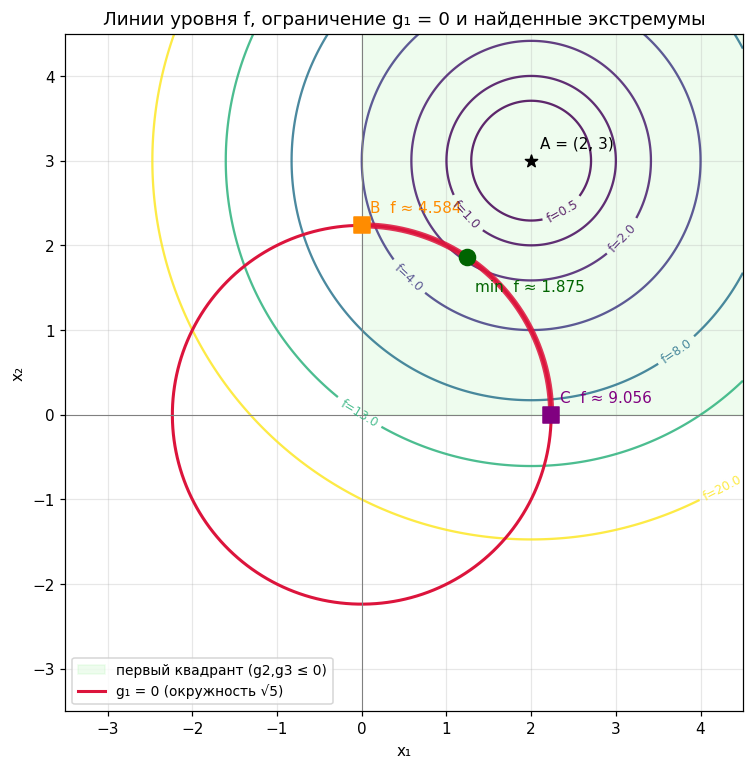

In [11]:
xx = np.linspace(-3.5, 4.5, 400)
yy = np.linspace(-3.5, 4.5, 400)
X, Y = np.meshgrid(xx, yy)
Z = (X - 2)**2 + (Y - 3)**2

fig, ax = plt.subplots(figsize=(9, 8))

# Затенённая допустимая область (только круг + первый квадрант — это не "область",
# а кривая; покажем сам первый квадрант полупрозрачным)
ax.fill_between([0, 5], 0, 5, color='lightgreen', alpha=0.15, label='первый квадрант (g2,g3 ≤ 0)')

# Линии уровня f
levels = [0.5, 1, 2, 4, 8, 13, 20]
cs = ax.contour(X, Y, Z, levels=levels, cmap='viridis', alpha=0.85)
ax.clabel(cs, inline=True, fontsize=8, fmt='f=%.1f')

# Окружность g1 = 0
theta = np.linspace(0, 2*np.pi, 400)
ax.plot(np.sqrt(5)*np.cos(theta), np.sqrt(5)*np.sin(theta),
        color='crimson', lw=2, label='g₁ = 0 (окружность √5)')
# Допустимая дуга в первом квадранте
theta_q = np.linspace(0, np.pi/2, 200)
ax.plot(np.sqrt(5)*np.cos(theta_q), np.sqrt(5)*np.sin(theta_q),
        color='crimson', lw=4, alpha=0.85)

# Точка A = (2,3)
ax.scatter([2], [3], color='black', s=70, marker='*', zorder=5)
ax.annotate('A = (2, 3)', (2, 3), xytext=(2.1, 3.15), fontsize=10)

# Найденные экстремумы
P_min = (x1_min, x2_min)
P_B = (0.0, float(np.sqrt(5)))
P_C = (float(np.sqrt(5)), 0.0)

ax.scatter(*P_min, color='darkgreen', s=110, marker='o', zorder=5)
ax.annotate(f'min  f ≈ {f_min_an:.3f}', P_min, xytext=(P_min[0]+0.1, P_min[1]-0.4), fontsize=10, color='darkgreen')

ax.scatter(*P_B, color='darkorange', s=110, marker='s', zorder=5)
ax.annotate(f'B  f ≈ {fB:.3f}', P_B, xytext=(P_B[0]+0.1, P_B[1]+0.15), fontsize=10, color='darkorange')

ax.scatter(*P_C, color='purple', s=110, marker='s', zorder=5)
ax.annotate(f'C  f ≈ {fC:.3f}', P_C, xytext=(P_C[0]+0.1, P_C[1]+0.15), fontsize=10, color='purple')

# Оси x1=0, x2=0
ax.axhline(0, color='gray', lw=0.7)
ax.axvline(0, color='gray', lw=0.7)

ax.set_xlim(-3.5, 4.5); ax.set_ylim(-3.5, 4.5)
ax.set_aspect('equal')
ax.set_xlabel('x₁'); ax.set_ylabel('x₂')
ax.set_title('Линии уровня f, ограничение g₁ = 0 и найденные экстремумы')
ax.legend(loc='lower left', fontsize=9)
ax.grid(alpha=0.3)
plt.show()

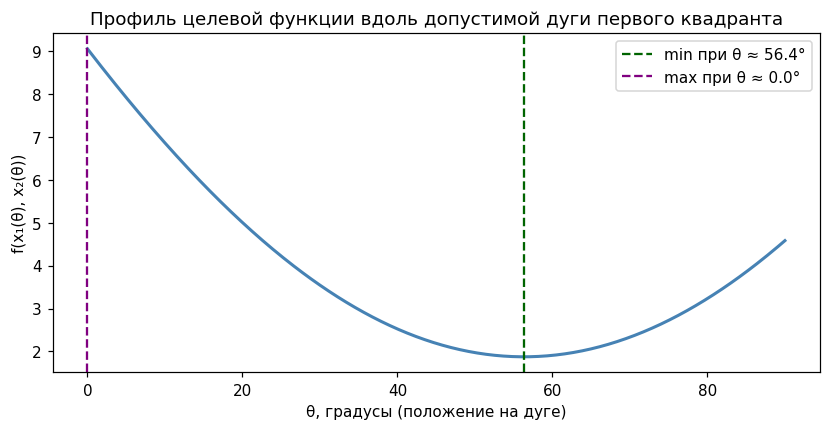

In [12]:
# Профиль f вдоль допустимой дуги, параметризованной углом
theta_q = np.linspace(0, np.pi/2, 400)
x_arc = np.sqrt(5) * np.cos(theta_q)
y_arc = np.sqrt(5) * np.sin(theta_q)
f_arc = (x_arc - 2)**2 + (y_arc - 3)**2

theta_min = np.arctan2(y_arc[np.argmin(f_arc)], x_arc[np.argmin(f_arc)])
theta_max = np.arctan2(y_arc[np.argmax(f_arc)], x_arc[np.argmax(f_arc)])

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(np.degrees(theta_q), f_arc, color='steelblue', lw=2)
ax.axvline(np.degrees(theta_min), color='darkgreen', ls='--', label=f'min при θ ≈ {np.degrees(theta_min):.1f}°')
ax.axvline(np.degrees(theta_max), color='purple', ls='--', label=f'max при θ ≈ {np.degrees(theta_max):.1f}°')
ax.set_xlabel('θ, градусы (положение на дуге)')
ax.set_ylabel('f(x₁(θ), x₂(θ))')
ax.set_title('Профиль целевой функции вдоль допустимой дуги первого квадранта')
ax.legend()
plt.show()

## Итоги

1. Поставлена задача условного экстремума (вариант 1.1 из методических указаний): минимизировать/максимизировать квадрат расстояния от точки $(2,3)$ до окружности радиуса $\sqrt{5}$ в первом квадранте.
2. Записана обобщённая функция Лагранжа; для регулярного случая $\lambda_0 = 1$ найдены условно-стационарные точки перебором активных ограничений (три допустимых кандидата).
3. Проверены **достаточные условия второго порядка двумя способами** — через знак $d^2 L$ на касательных приращениях и через определитель окаймлённого гессиана; результаты согласуются.
4. **Локальный минимум** достигается во внутренней точке дуги $x^* \approx (1.2403, 1.8605)$ при $f^* \approx 0.5572$; граничные точки $(0, \sqrt{5})$ и $(\sqrt{5}, 0)$ дают $f \approx 4.58$ и $\approx 9.06$ соответственно — кандидаты на локальный максимум по дуге (глобальный максимум по допустимой дуге — точка $C$ со значением $\approx 9.06$).
5. Численное решение методом SLSQP полностью подтверждает аналитический результат — независимо от стартовой точки сходится к тому же $x^*$.
6. Визуализация наглядно показывает, что линия уровня $f \approx 0.557$ касается окружности именно в точке $x^*$, а профиль $f$ вдоль дуги монотонно убывает от $C$ к минимуму и затем растёт к $B$ — что соответствует выводам по знакам $d^2 L$.